# Taller de IA — Parte 3: Leer etiquetas ArUco

En la **Parte 1** una red **aprendió** a leer dígitos y las volvió a clasificar con OpenCV. En la **Parte 2** (`02_taller_qr.ipynb`) el mismo `cv2` decodificó un **texto** para una app (SKU, catálogo).

Aquí el destino no es una app de inventario: es un **robot**. Pegamos un marcador ArUco, un cuadrado diseñado para que la cámara encuentre un **ID** y una **posición**. Tampoco entrenamos: OpenCV ya trae el detector.

La pregunta del taller no cambió: *¿qué hay en esta imagen?* Ahora la respuesta no es un string de producto, es “estación Almacén, en este punto de la foto”.

## Objetivo de esta parte

1. Generar un marcador (como imprimir una etiqueta)
2. Detectar su ID y sus esquinas
3. Leer tres estaciones en una sola escena (Entrada, Almacén, Salida)

No hace falta webcam ni robot físico. El extra del final es opcional, en casa.


## Paso 1: Preparar las herramientas

**Tarea**: Importar OpenCV, NumPy y Matplotlib.

**Enfoque**: `cv2` ya salió en las Partes 1 (dnn) y 2 (QR). Aquí usamos el módulo `aruco`.

- **OpenCV (`cv2`)** — diccionario y detector de ArUco
- **NumPy** — el lienzo y las coordenadas son arreglos
- **Matplotlib** — ver las imágenes *dentro* del notebook (evitamos `cv2.imshow`)


**Código**:

In [1]:
%matplotlib inline
import cv2
import numpy as np
import matplotlib.pyplot as plt

print("OpenCV versión:", cv2.__version__)
print("Módulo ArUco:", hasattr(cv2, "aruco"))


OpenCV versión: 5.0.0
Módulo ArUco: True


**Resultado**: OpenCV 5.0.0 y `Módulo ArUco: True`. El entorno de la Parte 3 está listo.

Siguiente: fabricar el primer marcador, el equivalente a “imprimir la etiqueta”.


## Paso 2: Generar un marcador

**Tarea**: Crear la imagen del marcador con ID 5.

**Enfoque**: Un diccionario ArUco es una lista de patrones. `DICT_4X4_50` son 50 IDs (0–49) en una cuadrícula 4×4. El ID es el número que leerá el detector.

`generateImageMarker` dibuja el patrón. Hay que dejar un **margen blanco**: si el cuadrado llega al borde, OpenCV no lo ve. Ese margen es el equivalente práctico a “no recortar la etiqueta al pegarla”.


**Código**:

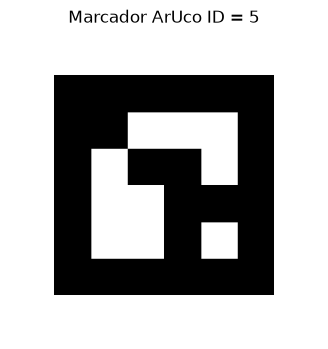

Forma: (280, 280) | ID que vamos a buscar: 5


In [2]:
# 50 patrones distintos de 4×4 bits; nos basta para etiquetar estaciones.
DICCIONARIO = cv2.aruco.getPredefinedDictionary(cv2.aruco.DICT_4X4_50)


def generar_marcador(id_marcador, tamano=200, margen=40):
    """Imagen en escala de grises del marcador `id_marcador`, con margen blanco."""
    nucleo = cv2.aruco.generateImageMarker(DICCIONARIO, id_marcador, tamano)
    return cv2.copyMakeBorder(
        nucleo, margen, margen, margen, margen,
        cv2.BORDER_CONSTANT, value=255,
    )


def mostrar(img, titulo=""):
    """Muestra una imagen de OpenCV (gris o BGR) en el notebook."""
    plt.figure(figsize=(4, 4))
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(titulo)
    plt.axis("off")
    plt.show()


marcador_5 = generar_marcador(5)
mostrar(marcador_5, "Marcador ArUco ID = 5")
print("Forma:", marcador_5.shape, "| ID que vamos a buscar: 5")


**Resultado**: Un cuadrado negro y blanco. Ese patrón **es** el 5 para el detector: no es un dígito manuscrito como en la Parte 1, es una etiqueta diseñada.

Siguiente: pedirle a OpenCV que lo lea.


## Paso 3: Detectar ID y esquinas

**Tarea**: Pasar la imagen al detector y dibujar lo que encontró.

**Enfoque**: `detectMarkers` devuelve:

- **esquinas** — los 4 vértices, en píxeles
- **ids** — el número leído
- **rechazados** — cuadrados que parecían marcadores y no coincidieron con el diccionario

El **centro** (promedio de las esquinas) es la posición 2D: “el almacén está a la izquierda de la foto”.


**Código**:

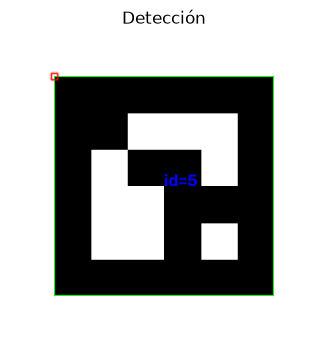

IDs encontrados: [5]
Centro en la imagen: (139.5, 139.5) píxeles


In [3]:
detector = cv2.aruco.ArucoDetector(
    DICCIONARIO,
    cv2.aruco.DetectorParameters(),
)


def detectar(img_gris):
    """Devuelve (esquinas, ids) usando el diccionario 4×4."""
    esquinas, ids, _rechazados = detector.detectMarkers(img_gris)
    if ids is None:
        ids = np.array([])
    else:
        ids = ids.flatten()
    return esquinas, ids


def dibujar_deteccion(img_gris, esquinas, ids):
    vis = cv2.cvtColor(img_gris, cv2.COLOR_GRAY2BGR)
    cv2.aruco.drawDetectedMarkers(vis, esquinas, ids.reshape(-1, 1) if len(ids) else None)
    return vis


esquinas, ids = detectar(marcador_5)
vis = dibujar_deteccion(marcador_5, esquinas, ids)
mostrar(vis, "Detección")

print("IDs encontrados:", ids.tolist() if len(ids) else "ninguno")
if len(ids):
    # Las 4 esquinas del primer marcador; el centro es su promedio.
    pts = esquinas[0].reshape(4, 2)
    cx, cy = pts.mean(axis=0)
    print(f"Centro en la imagen: ({cx:.1f}, {cy:.1f}) píxeles")


**Resultado**: Recuadro sobre el marcador, ID 5, centro a mitad de la imagen (~140, 140). Si no saliera ningún ID, lo primero a revisar es el margen blanco.

Siguiente: tres etiquetas a la vez, como estaciones de un almacén pequeño.


## Paso 4: Tres estaciones en una imagen

**Tarea**: Pegar tres marcadores (Entrada = 3, Almacén = 7, Salida = 12) y listar qué estación aparece dónde.

**Enfoque**: Un programa de robot no “entiende” la foto. Busca cuadrados ArUco y consulta una tabla `ID → nombre`. Misma idea que el QR de la Parte 2 (imagen → código → tabla), pero el código es un ID de estación, no un SKU de una app.


**Código**:

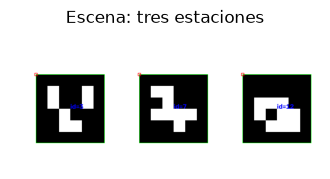

ID | estación  | centro (x, y)
---+-----------+---------------
 3 | Entrada   | (140, 180)
 7 | Almacén   | (380, 180)
12 | Salida    | (620, 180)


In [4]:
# Tabla que el robot tendría en código: ID del marcador → estación.
ESTACIONES = {
    3: "Entrada",
    7: "Almacén",
    12: "Salida",
}

ALTO, ANCHO = 320, 720
TAM = 160
lienzo = np.full((ALTO, ANCHO), 255, dtype=np.uint8)

# Tres posiciones fijas, de izquierda a derecha.
colocaciones = [
    (3, 40, 80),
    (7, 280, 80),
    (12, 520, 80),
]
for id_m, x, y in colocaciones:
    m = generar_marcador(id_m, tamano=TAM, margen=20)
    h, w = m.shape
    lienzo[y:y + h, x:x + w] = m

esquinas, ids = detectar(lienzo)
vis = dibujar_deteccion(lienzo, esquinas, ids)
mostrar(vis, "Escena: tres estaciones")

print("ID | estación  | centro (x, y)")
print("---+-----------+---------------")
if len(ids) == 0:
    print("No se detectó ningún marcador")
else:
    filas = []
    for i, id_m in enumerate(ids):
        pts = esquinas[i].reshape(4, 2)
        cx, cy = pts.mean(axis=0)
        nombre = ESTACIONES.get(int(id_m), "(ID no está en la tabla)")
        filas.append((cx, int(id_m), nombre, cy))
    filas.sort()  # izquierda → derecha
    for cx, id_m, nombre, cy in filas:
        print(f"{id_m:2d} | {nombre:<9} | ({cx:.0f}, {cy:.0f})")


**Resultado**: De izquierda a derecha: Entrada (3) en x≈140, Almacén (7) en x≈380, Salida (12) en x≈620. Esa tabla es la percepción: *qué* hay y *dónde*.

Con esto cierra el objetivo de la Parte 3.


## Cierre de la Parte 3

Sin entrenar nada, OpenCV respondió *¿qué hay en la imagen?*: un **ID** y un **dónde** (esquinas / centro).

### Qué aprendimos
1. En robótica se usan etiquetas diseñadas, no dígitos a mano
2. ArUco necesita margen blanco
3. El detector entrega ID + 4 esquinas
4. Una tabla ID → nombre convierte eso en “estoy viendo el Almacén”

### Cómo encaja en el taller

| | Parte 1 | Parte 2 | Parte 3 (esta) |
|---|---|---|---|
| Pregunta | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? | ¿Qué hay en la imagen? |
| Respuesta | un dígito 0–9 | un texto (SKU, URL…) | un ID de estación |
| Herramienta | red que **aprendimos** | decoder QR de OpenCV | detector ArUco de OpenCV |
| Dónde se usa | patrón sucio / variable | apps, tickets, inventario | robots, almacén, pose |

Tres partes hasta aquí: primero enseñas a ver; después lees un código de software; luego una etiqueta de robot.

### Siguiente: Parte 4

Abre `04_taller_moda.ipynb`. Dataset abierto de ropa (Fashion-MNIST) y un **reto** con OpenCV: distinguir calzado sin entrenar una red.

### Extra: webcam (opcional, en casa)

Imprime o muestra en el celular el marcador ID 5 y, en una celda nueva, ejecuta:

```python
def ver_camara():
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("No hay cámara")
        return
    while True:
        ok, frame = cap.read()
        if not ok:
            break
        gris = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        esquinas, ids = detectar(gris)
        vis = frame.copy()
        if len(ids):
            cv2.aruco.drawDetectedMarkers(vis, esquinas, ids.reshape(-1, 1))
        cv2.imshow("ArUco (q para salir)", vis)
        if cv2.waitKey(1) & 0xFF == ord("q"):
            break
    cap.release()
    cv2.destroyAllWindows()

# ver_camara()
```
